# Regresión lineal

En este notebook trabajaremos con datos simulados para estudiar:

- cómo se ajusta una regresión lineal
- cómo se evalúa un modelo de regresión
- cómo cambia el ajuste frente a outliers
- cómo funciona Gradient Descent
- cómo Ridge, Lasso y Elastic Net modifican los coeficientes.


Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)



## Instrucciones

Este notebook combina celdas demostrativas con preguntas de análisis.

No basta con ejecutar el código: deben interpretar los resultados, comparar métricas y justificar sus respuestas usando gráficos, coeficientes y residuos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.model_selection import KFold
from sklearn import linear_model # Nuevo modelo desbloqueado

font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14) 
#matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 150

In [2]:
from sklearn.metrics._scorer import _SCORERS

#### Generamos un dataset de juguete

Primero trabajaremos con datos simulados. La ventaja es que conocemos la relación verdadera:
$$
y_{\rm true} = 3x + 3
$$

Luego agregamos ruido para simular mediciones imperfectas.

In [3]:
np.random.seed(16) #fijar semilla para la reproducibilidad

x = np.arange(100) 

yp = 3*x + 3 + 2*(np.random.poisson(3*x+3,100)-(3*x+3)) 
#genera datos con dispersión, siguiendo una distribución Poissoniana
# con valor esperado = y (modelo lineal), centrado alrededor de cero

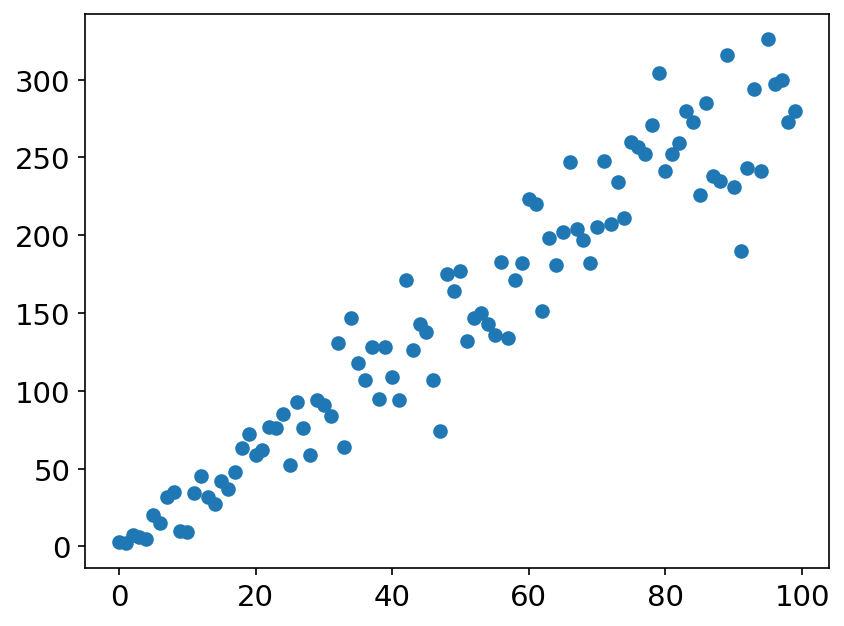

In [4]:
plt.scatter(x, yp);

### Pregunta 

De acuerdo al gráfico anterior:
- ¿Los datos siguen una tendencia aproximadamente lineal?  
R: Sí, podríamos ajustar una recta a los daots
- ¿La dispersión alrededor de la recta parece constante para todos los valores de \(x\)?  
R: No, para $x$ más grandes la dispersión tiende a aumentar.
- ¿Qué podría implicar esto al mirar residuos más adelante?  
R: Veríamos que los residuos crecen al aumentar $x$ en el modelo.

In [5]:
model = linear_model.LinearRegression()

#### Ajuste con regresión lineal

Ajustaremos un modelo de la forma:

$$
\hat{y} = \beta_0 + \beta_1 x
$$

En `sklearn`, cuando tenemos una sola feature, necesitamos escribir `x` como una matriz de forma `(n_samples, 1)`. Por eso usamos:

```python
x.reshape(-1, 1)

In [6]:
model.fit(x.reshape(-1, 1), yp)

LinearRegression()

In [7]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Intercepto beta_0 = {intercept:.3f}")
print(f"Pendiente beta_1 = {slope:.3f}")

Intercepto beta_0 = -0.126
Pendiente beta_1 = 3.025


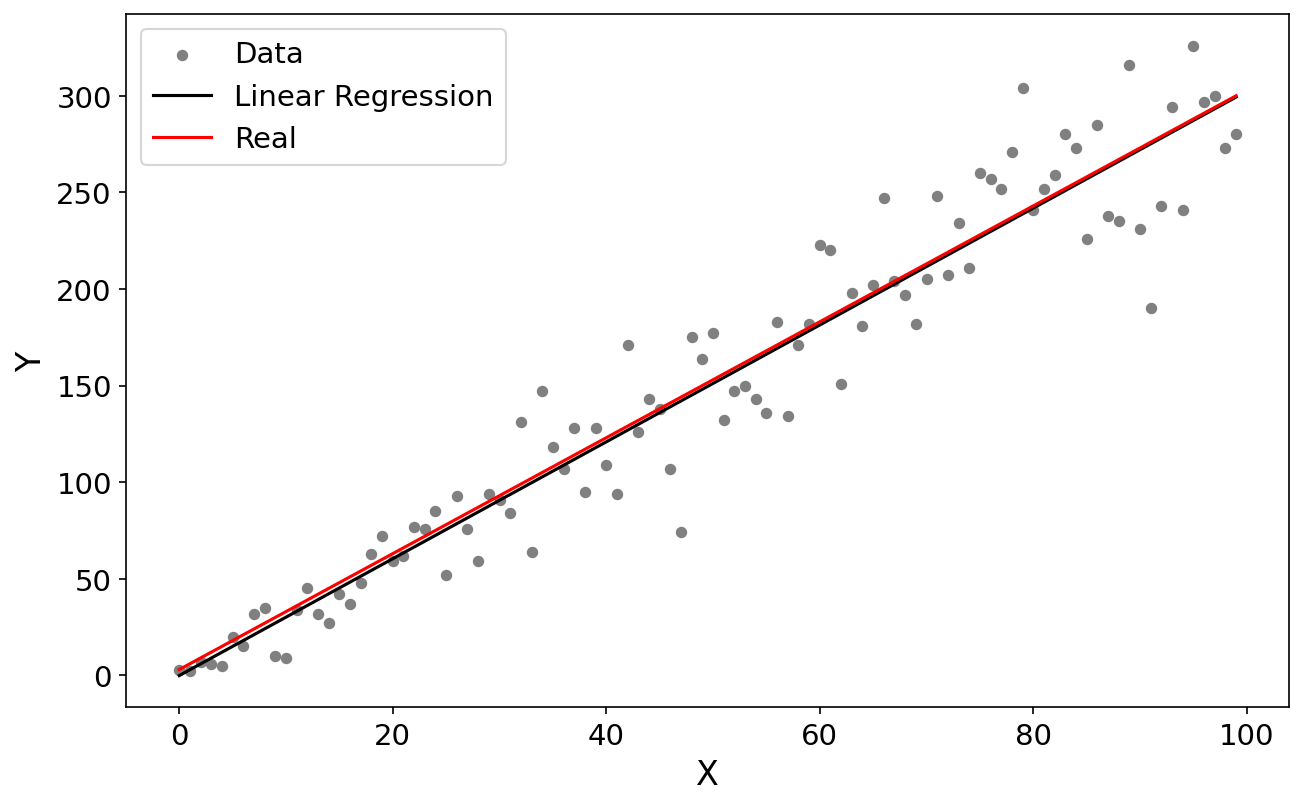

In [8]:
plt.figure(figsize = (10,6))
plt.scatter(x,yp, s = 20, c = 'gray', label = 'Data')
plt.plot(x, slope*x + intercept, c ='k', label = 'Linear Regression')
plt.plot(x, 3*x + 3, c = 'r', label = 'Real')
plt.legend(fontsize = 14)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

### Pregunta

Compara los coeficientes ajustados con los valores verdaderos $\beta_0=3$ y $\beta_1=3$
-  ¿Son exactamente iguales? ¿Por qué?
R: No, los errores para $x$ grande contribuyeron a que el modelo varíe respecto al real
-  ¿Qué representa físicamente/matemáticamente la pendiente en este modelo?
R: Es una tasa de crecimiento, cuán rápido crece el valor de $y$ con respecto a $x$. Es claro al calcular la derivada, pues $y' = \beta_1$

#### Solución analítica de mínimos cuadrados

Para regresión lineal simple, la pendiente que minimiza el MSE puede escribirse como:

$$
\beta_1 =
\frac{\sum_i (x_i-\bar{x})(y_i-\bar{y})}
{\sum_i (x_i-\bar{x})^2}
$$

y luego:

$$
\beta_0 = \bar{y} - \beta_1\bar{x}
$$

**Implemente en el código para calcular a partir de la solución analítica los coeficientes y compare**

In [9]:
y_mean = np.mean(yp)
x_mean = np.mean(x)

beta1= np.sum((x - x_mean)*(yp-y_mean))/np.sum((x - x_mean)**2)

beta0= y_mean - beta1*x_mean

print(f"Beta_0 analítico = {beta0:.3f}")
print(f"Beta_1 analítico = {beta1:.3f}")

print(f"Beta_0 sklearn = {intercept:.3f}")
print(f"Beta_1 sklearn = {slope:.3f}")

Beta_0 analítico = -0.126
Beta_1 analítico = 3.025
Beta_0 sklearn = -0.126
Beta_1 sklearn = 3.025


#### Evaluación del modelo: validación cruzada y métricas

Ahora aplicamos una idea que ya usamos en clasificación: validar el modelo en distintos subconjuntos de datos.

Por defecto, `LinearRegression.score()` devuelve \(R^2\), no accuracy.

Podemos ver todos los scorers implementados en sklearn

In [10]:
from sklearn.metrics import get_scorer_names
print(get_scorer_names())

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_macro', 'recall_micro', 'recall_samples'

#### Implemente una validación cruzada con Kfold

y encuentre los resultados para las métricas R^2, 'neg_mean_absolute_error'  (MAE) y 'neg_mean_squared_error' (MSE)

Para los estimadores de la performance del modelo del tipo "error" siempre queremos que sean pequeños (menor error, mejor modelo). Pero en sklearn, reciben un signo negativo, como neg_mean_squared_error, para mantener la consistencia de "alto puntaje=mejor" de los scorers

In [11]:
scores_r2 = cross_validate(model, x.reshape(-1, 1), yp, cv=5, scoring='r2', return_train_score=True)#implemente una validacion cruzada
print(f"R2 test : {scores_r2['test_score'].mean():.3f} ± {scores_r2['test_score'].std():.3f}")
print(f"R2 train: {scores_r2['train_score'].mean():.3f} ± {scores_r2['train_score'].std():.3f}")

R2 test : 0.273 ± 0.319
R2 train: 0.917 ± 0.027


In [12]:
scores_mse = cross_validate(model, x.reshape(-1, 1), yp, cv=5, scoring='neg_mean_squared_error', return_train_score=True)#implemente una validacion cruzada

scores_mae = cross_validate(model, x.reshape(-1, 1), yp, cv=5, scoring='neg_mean_absolute_error', return_train_score=True)#implemente una validacion cruzada

print(f"MSE test: {-scores_mse['test_score'].mean():.3f}")
print(f"MAE test: {-scores_mae['test_score'].mean():.3f}")

MSE test: 712.979
MAE test: 19.711


**Haga un gráfico de los residuos $r_i=y_i-\hat{y}_i$**

Text(0, 0.5, 'Residuos')

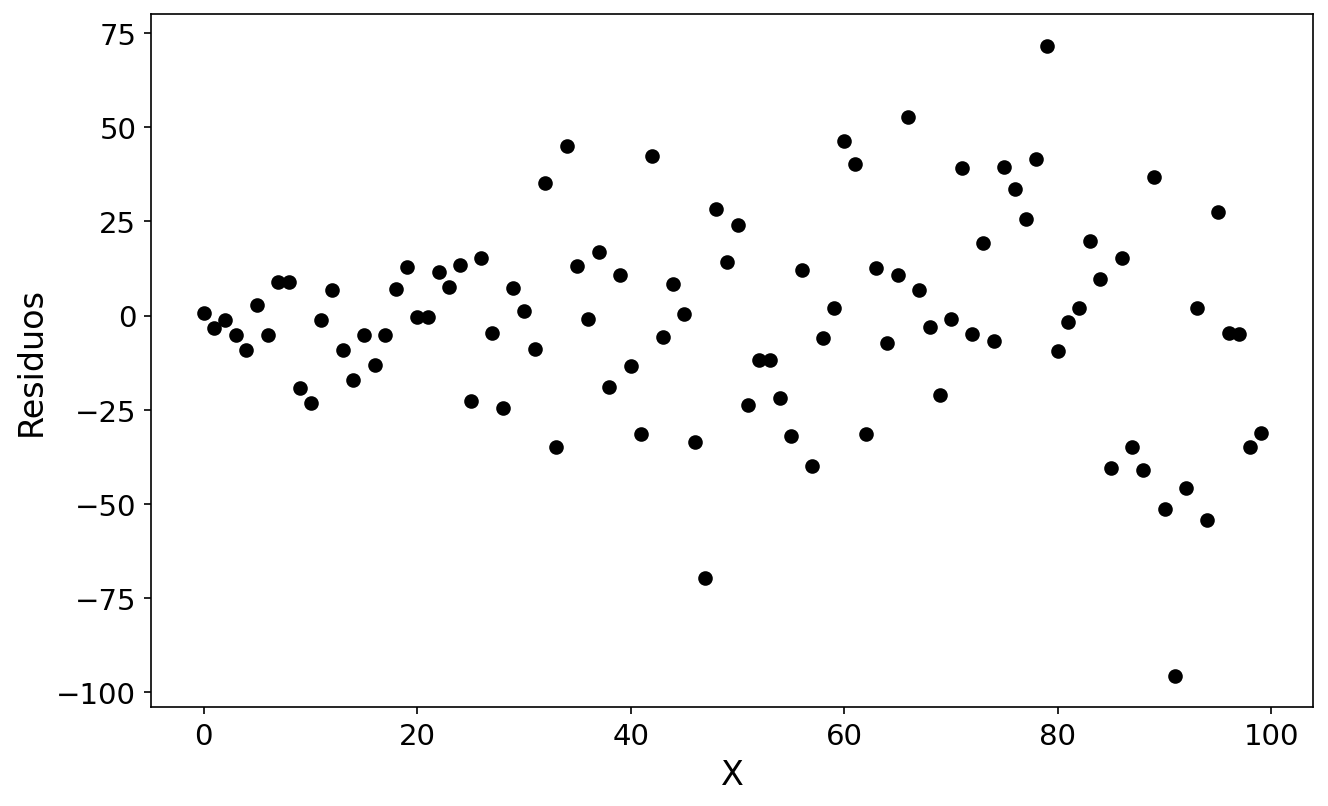

In [13]:
predictions = cross_val_predict(model, x.reshape(-1, 1), yp, cv=5)
res = yp - predictions

plt.figure(figsize = (10,6))
plt.scatter(x, res, color="k")
plt.xlabel("X")
plt.ylabel("Residuos")

#### Pregunta 
-  ¿Los residuos parecen distribuidos aleatoriamente alrededor de cero?  
R: No, al aumentar $x$ notamos que aumentan los residuos.
-  ¿La dispersión de los residuos cambia con $x$?  
R: En efecto, al aumentar $x$ aumenta la dispersión
-  ¿Qué nos dice esto sobre el modelo y/o sobre cómo fueron generados los datos?  
R: El error generado para los datos es proporcional a $x$.

### ¿Qué ocurre si agregamos outliers?

In [14]:
np.random.seed(12) # fijada la semilla
out = np.random.choice(100,15) #seleccionamos 15 índices de outliers
yp_wo = np.copy(yp)
np.random.seed(12) #fijada 
yp_wo[out] = yp_wo[out] + 5*np.random.rand(15)*yp[out]

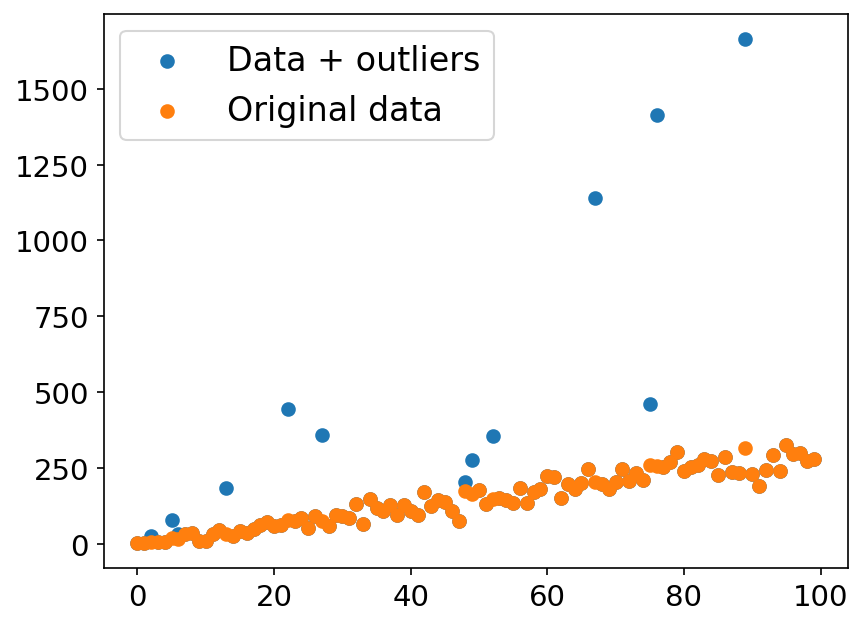

In [15]:
plt.scatter(x,yp_wo, label = 'Data + outliers')
plt.scatter(x,yp, label = 'Original data')
plt.legend();

#### Ajuste el modelo de regresión lineal para los datos con outliers

Responda: 
- Compare visualmente el ajuste antes y después de agregar outliers. ¿La recta cambia mucho? ¿Hacia dónde se mueve?
- Compara los coeficientes $\beta_0$ y $\beta_1$ del modelo con y sin outliers.  ¿Cuál cambia más: el intercepto o la pendiente?
- Compara las métricas MAE, MSE, RMSE y $R^2$ antes y después de agregar outliers. ¿Qué métrica se ve más afectada?
- ¿Por qué el MSE/RMSE suele ser más sensible a outliers que el MAE?
- ¿Todos los outliers afectan de la misma manera al modelo? Observa si los puntos atípicos están lejos en $y$, lejos en $x$, o en ambos.
- ¿Dirías que el modelo con outliers está aprendiendo la tendencia general de los datos o está siendo “tirado” por algunos puntos extremos? Justifica.
- Si este fuera un dataset real, ¿eliminarías los outliers automáticamente? Explica qué revisarías antes de decidir.

In [16]:
model_outliers = linear_model.LinearRegression() #implemente el modelo aca
model_outliers.fit(x.reshape(-1, 1), yp_wo)

y_pred = model_outliers.predict(x.reshape(-1, 1))

r2_ol = metrics.r2_score(yp_wo, y_pred)
mae_ol = metrics.mean_absolute_error(yp_wo, y_pred)
mse_ol = metrics.mean_squared_error(yp_wo, y_pred)
rmse_ol = np.sqrt(mse_ol)

print(f"R2   = {r2_ol:.3f}")
print(f"MAE  = {mae_ol:.3f}")
print(f"MSE  = {mse_ol:.3f}")
print(f"RMSE = {rmse_ol:.3f}", end="\n\n")
print(f"R2 sin outliers = {scores_r2['test_score'].mean():.3f} ± {scores_r2['test_score'].std():.3f}")
print(f"MAE sin outliers = {-scores_mae['test_score'].mean():.3f}")
print(f"MSE sin outliers = {-scores_mse['test_score'].mean():.3f}")
print(f"RMSE sin outliers = {np.sqrt(-scores_mse['test_score'].mean()):.3f}")


R2   = 0.234
MAE  = 90.514
MSE  = 43259.082
RMSE = 207.988

R2 sin outliers = 0.273 ± 0.319
MAE sin outliers = 19.711
MSE sin outliers = 712.979
RMSE sin outliers = 26.702


Del resultado del modelo lineal para estos datos con outliers, guarde los coeficientes encontrados en un array llamado `theta_ne`

Intercepto beta_0 con outliers = 1.548
Pendiente beta_1 con outliers = 3.978


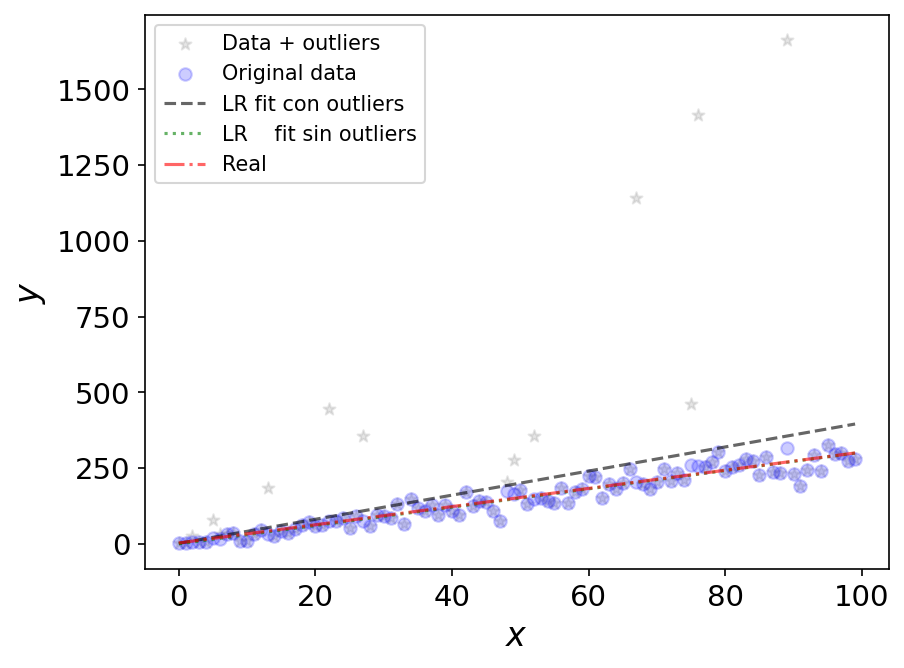

In [17]:
slope_outl = model_outliers.coef_[0]
intercept_outl = model_outliers.intercept_
print(f"Intercepto beta_0 con outliers = {intercept_outl:.3f}")
print(f"Pendiente beta_1 con outliers = {slope_outl:.3f}")
theta_ne = np.array([slope_outl, intercept_outl])

plt.figure()
plt.scatter(x, yp_wo, label = 'Data + outliers', color = 'gray', alpha=0.2, marker="*")
plt.scatter(x, yp, label = 'Original data', color = 'blue', alpha=0.2)
plt.plot(x, slope_outl*x + intercept_outl, c = 'k', label = 'LR fit con outliers',
         linestyle = '--', alpha=0.6)
plt.plot(x, slope*x + intercept, c = 'g', label = 'LR    fit sin outliers',
         linestyle = ':', alpha=0.6)
plt.plot(x, 3*x + 3, c = 'r', label = 'Real',
         linestyle = 'dashdot', alpha=0.6 )
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend(fontsize = 10)
plt.show()

- La recta se desplaza hacia arriba, pues los outliers están hacia arriba
- Ambos $\beta$ aumentaron en 1 aprox., pero es más notorio el efecto de la pendiente para estos efectos.
- El MSE fue el más afectado
- Esto pues el MSE penaliza los errores al tener los residuos al cuadrado, en cambio MAE sólo toma la diferencia absoluta.
- Los outliers están construidos lejos en $y$, a medida que $x$ crece.
- Los outliers presentes tiran del modelo hacia arriba afectando las predicciones realizadas.
- Sería ideal revisar los datos desde la perspectiva física y el origen de estos. El descarte de outliers se debería hacer con la certeza de que son datos sucios y no representan la situación a modelar. De todas formas hay maneras de considerar los outliers como parte del modelo y tener en cuenta el error que introducen.

Esto es la solución usando el modelo y la **ecuación normal**

### Ahora implementaremos 3 métodos de gradient descent: batch, estocástico y mini-batch

En esta sección ajustamos una regresión lineal usando Gradient Descent en vez de usar directamente `LinearRegression`. Compararemos con los resultados encontrados en la regresión con outliers.




Agregaremos $x_0=1$ a cada instancia, este es el término de bias ($\beta_0$) y se usa para escribir la solución en la forma de multiplicación de matrices 

$y=X\cdot \theta$

donde $\theta$ es el vector de coeficientes que incluye el término $\beta_0$  (término de bias) y $\beta_1, \beta_2, \beta_3,..., \beta_n$

In [18]:
X = np.c_[np.ones((100, 1)), x]  

print(X.shape) #la forma es el número de instancias x número de parámetros


(100, 2)


Podemos calcular la pérdida asociada con la ecuación normal, usando la expresión 

$\text{MSE} = \frac{1}{m}\|X\cdot \theta - y \|^2$

In [19]:
loss_ne = np.mean((X.dot(theta_ne) - yp_wo.reshape(-1,1))**2)

### Batch GD

In [20]:
np.random.seed(10) 

eta = 0.0001 #learning step (valor pequeño asegura convergencia, aunque lenta)
n_iterations = 1000 #puede cambiar este valor!!
m = 100 #número de instancias

theta_path_bgd = [] #arreglo para guardar los valores de los parámetros en cada iteración

theta = np.random.randn(2,1) #inicializamos con valores aleatorios

for iteration in range(n_iterations):
    gradients = 2/m * X.T.dot(X.dot(theta) - yp_wo.reshape(-1,1)) #gradiente de la función de pérdida respecto a theta
    theta = theta - eta * gradients #actualiza los valores de theta, en cada cálculo del gradiente, en cada paso
    theta_path_bgd.append(theta) #

theta_path_bgd = np.array(theta_path_bgd) #guardamos esos valores (útil para una visualización)

theta_bgd = theta #resultado final

In [21]:
theta_bgd

array([[1.38909891],
       [3.98081931]])

In [22]:
loss_bgd = np.sum(1/m*(X.dot(theta_bgd) - yp_wo.reshape(-1,1))**2)

In [23]:
loss_bgd

43259.08804185896

In [24]:
(loss_ne-loss_bgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

40.19860273406647

###  GD estocástico

In [25]:
np.random.seed(10) #

theta = np.random.randn(2,1)  #inicializa los parámetros

eta = 0.000005 #learning step, valor más pequeño evita saltos muy grandes

n_iterations = 10000 #necesitamos más iteraciones en este caso

theta_path_sgd = []

for epoch in range(n_iterations):
    
        random_index = np.random.randint(m) #índice aleatorio
        
        x_one = X[random_index:random_index+1] #sólo se selecciona una instancia del conjunto de datos (m es la cantidad total)
        
        y_one = yp_wo[random_index:random_index+1] 
        
        gradients = 2 * x_one.T.dot(x_one.dot(theta) - y_one)
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)                 

theta_path_sgd = np.array(theta_path_sgd)

theta_sgd = theta

In [26]:
theta_sgd

array([[1.3552955 ],
       [4.17721319]])

In [27]:
loss_sgd = np.sum(1/m*(X.dot(theta_sgd) - yp_wo.reshape(-1,1))**2)

In [28]:
loss_sgd

43385.08132655123

In [29]:
(loss_ne-loss_sgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

40.02442951840756

### Mini batch GD

In [30]:
# See also implementation notes here: https://sebastianraschka.com/faq/docs/sgd-methods.html

np.random.seed(10)

theta = np.random.randn(2,1) 

eta = 0.000005

n_iterations = 1000

theta_path_mgd = []

minibatch_size = 10 

for epoch in range(n_iterations):
    
    shuffled_indices = np.random.permutation(m) #se desordena el arreglo para seleccionar distintos mini-batches
    
    X_shuffled = X[shuffled_indices]
    
    y_shuffled = yp_wo.reshape(-1,1)[shuffled_indices]
    
    xi = X_shuffled[:minibatch_size] #subset aleatorio para calcular el gradiente
    
    yi = y_shuffled[:minibatch_size]
    
    gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)
    
    theta = theta - eta * gradients
    
    theta_path_mgd.append(theta)

theta_path_mgd = np.array(theta_path_mgd)

theta_mgd = theta 

print(theta_mgd)

[[1.38191988]
 [4.25542902]]


In [38]:
print(theta_mgd)
print(theta_ne)

[[1.38191988]
 [4.25542902]]
[3.97842184 1.54811881]


In [32]:
loss_mgd = np.sum(1/m*(X.dot(theta_mgd) - yp_wo.reshape(-1,1))**2)

In [33]:
loss_mgd

43506.50418469318

In [34]:
(loss_ne-loss_mgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

39.85657446399944

#### Comparación de GD
Veamos el camino que siguió cada método de GD que implementamos. El color más oscuro indica pasos posteriores

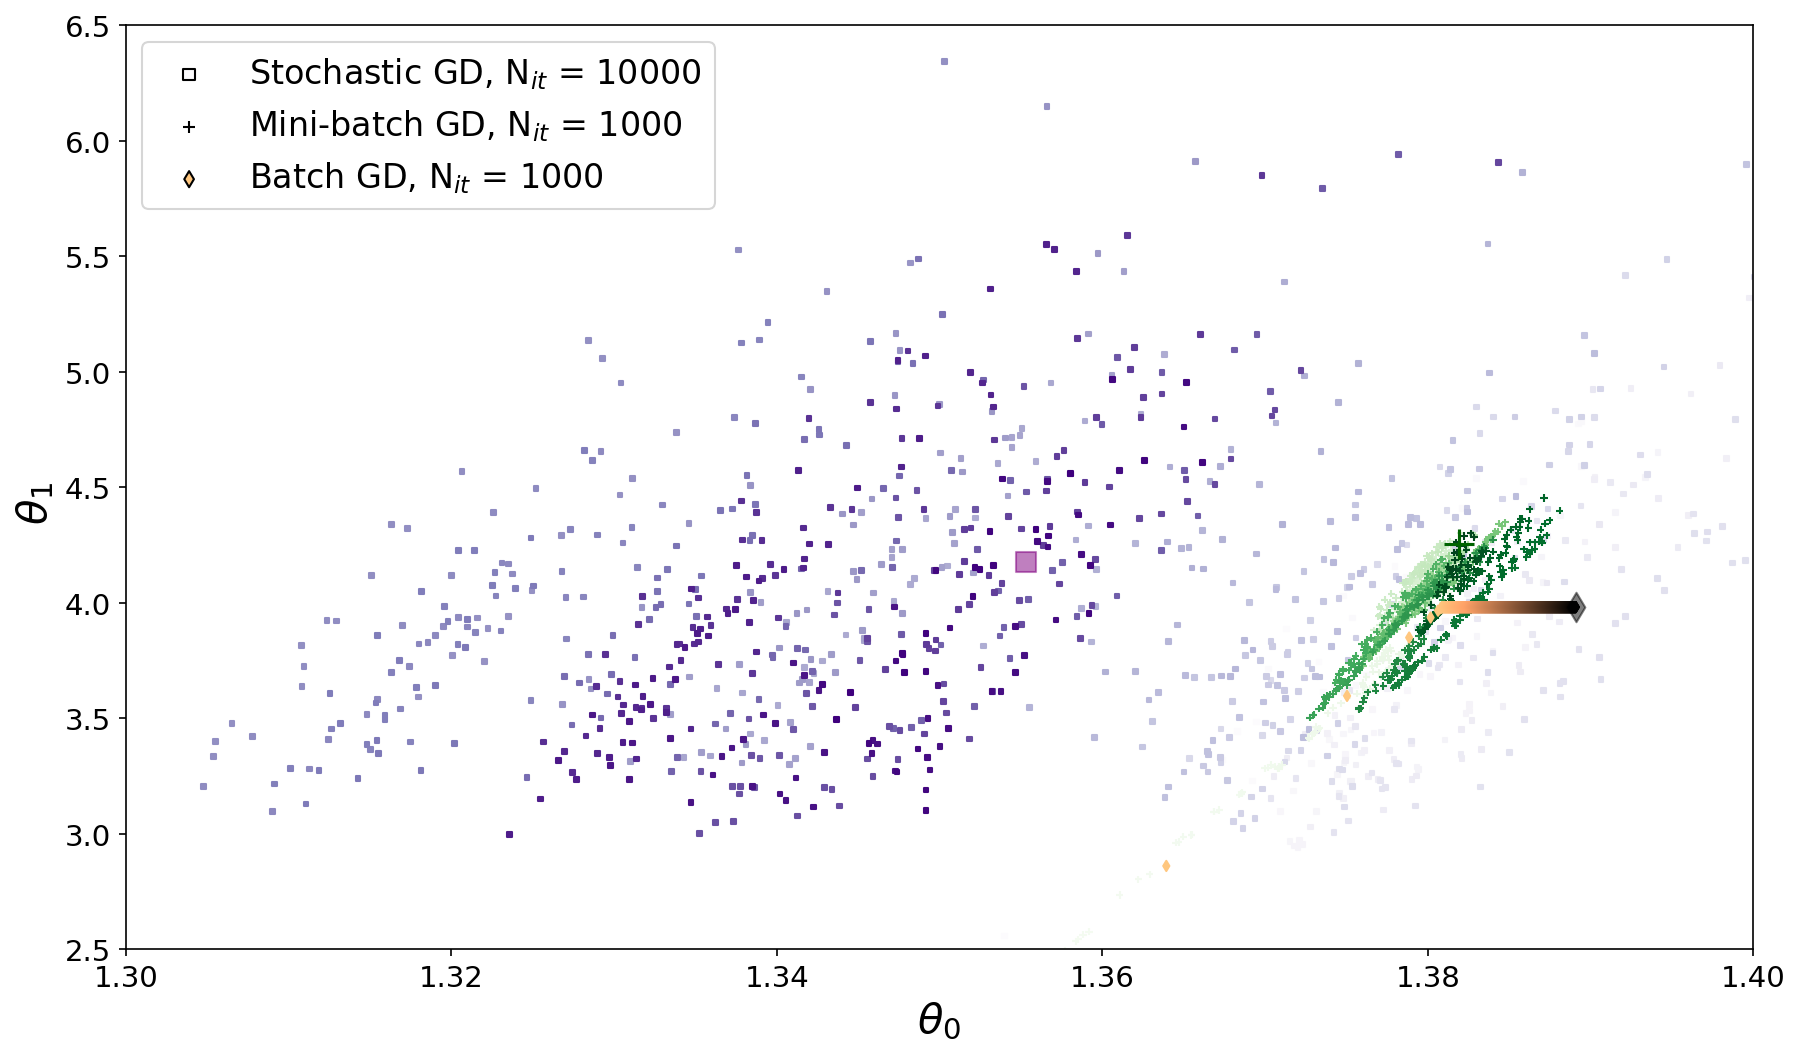

In [35]:
plt.figure(figsize=(14,8))

plt.scatter(theta_path_sgd[::10, 0].flatten(), theta_path_sgd[::10, 1].flatten(), marker = 's', s = 5, \
         label="Stochastic GD, N$_{it}$ = 10000", c = np.arange(1000), cmap=plt.cm.Purples)
plt.scatter(theta_path_mgd[:, 0].flatten(), theta_path_mgd[:, 1].flatten(), marker = "+", s = 12, linewidth=1, \
            label="Mini-batch GD, N$_{it}$ = 1000", c = np.arange(1000), cmap=plt.cm.Greens)
plt.scatter(theta_path_bgd[:, 0].flatten(), theta_path_bgd[:, 1].flatten(), marker = "d", s = 12, linewidth=1, \
            label="Batch GD, N$_{it}$ = 1000", c = np.arange(1000,0,-1), cmap=plt.cm.copper)

plt.scatter(theta_sgd[0],theta_sgd[1], marker = "s", s = 100, color = 'Purple', alpha = 0.5)
plt.scatter(theta_mgd[0],theta_mgd[1], marker = "+", s = 200, color = 'DarkGreen', alpha = 1)
plt.scatter(theta_bgd[0],theta_bgd[1], marker = "d", s = 100, color = 'k', alpha = 0.5)

legend = plt.legend(loc="upper left", fontsize=16)


for i in range(3):

    for i in range(3):
        legend.legend_handles[i].set_color('k')
        legend.legend_handles[i].set_sizes([30])

plt.xlabel(r"$\theta_0$", fontsize=20)
plt.ylabel(r"$\theta_1$   ", fontsize=20)

plt.axis([1.3, 1.4, 2.5, 6.5])

#plt.savefig('AllThePaths.png', dpi = 300)
plt.show()


### Preguntas

1. Identifica en el código de mini batch GD dónde ocurre cada paso:

   - cálculo de las predicciones
   - cálculo del error o residuo
   - cálculo del gradiente
   - actualización de los parámetros

2. ¿Qué representan los parámetros $\theta_0$ y $\theta_1$ en este modelo?

3. Compara los parámetros encontrados por Gradient Descent con los obtenidos mediante `LinearRegression`. ¿Son iguales o parecidos? ¿Por qué no necesariamente coinciden exactamente?


4. Cambia el learning rate $\eta$. Prueba al menos tres valores: uno pequeño, uno razonable y uno demasiado grande. ¿Qué ocurre en cada caso?


5. Explica con tus palabras por qué la actualización tiene un signo menos: $\theta \leftarrow \theta - \eta \nabla L$

6. En la solución analítica derivamos e igualamos a cero. En Gradient Descent no resolvemos directamente la ecuación.  ¿Qué hacemos en cambio?

7. Compara Batch Gradient Descent, Stochastic Gradient Descent y Mini-batch Gradient Descent.

   - ¿Cuál usa todos los datos en cada actualización?
   - ¿Cuál actualiza los parámetros con más ruido?
   - ¿Cuál parece converger de forma más suave?

In [41]:
# See also implementation notes here: https://sebastianraschka.com/faq/docs/sgd-methods.html

np.random.seed(10)

theta_results = {}

eta_values = [1e-6, 5e-6, 5e-4] 

for eta in eta_values:
    np.random.seed(10)
    theta = np.random.randn(2, 1)
    n_iterations = 1000
    minibatch_size = 10
    theta_path_mgd = []

    for epoch in range(n_iterations):
        shuffled_indices = np.random.permutation(m)
        X_shuffled = X[shuffled_indices]
        y_shuffled = yp_wo.reshape(-1, 1)[shuffled_indices]

        xi = X_shuffled[:minibatch_size]
        yi = y_shuffled[:minibatch_size]

        gradients = 2 / minibatch_size * xi.T.dot(xi.dot(theta) - yi)
        theta = theta - eta * gradients
        theta_path_mgd.append(theta)

    theta_path_mgd = np.array(theta_path_mgd)
    theta_results[eta] = {
        "theta": theta,
        "path": theta_path_mgd,
        "loss": np.mean((X.dot(theta) - yp_wo.reshape(-1, 1)) ** 2)
    }

    print(f"eta = {eta:g}")
    print(f"theta =\n{theta}")
    print(f"loss = {theta_results[eta]['loss']:.3f}")
    print("-" * 30)

eta = 1e-06
theta =
[[1.38221508]
 [4.07579452]]
loss = 43288.642
------------------------------
eta = 5e-06
theta =
[[1.38191988]
 [4.25542902]]
loss = 43506.504
------------------------------
eta = 0.0005
theta =
[[nan]
 [nan]]
loss = nan
------------------------------


/tmp/ipykernel_3753/325128315.py:25: RuntimeWarning: invalid value encountered in subtract
  theta = theta - eta * gradients


1. 
- `xi.dot(theta)`
- `xi.dot(theta) - yi`
- `gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)`
- `theta = theta - eta*gradients`

2. $\theta_0$ corresponde al intercepto y $\theta_1$ la pendiente de la regresión lineal

3. `LinearRegression` busca ser un método exacto (aunque entiendo que no resuelve la ecuación normal), mientras que GD es una aproximación al problema de minimización. La pendiente difiere un poco, y el intercepto es bastante similar entre sí.

4. Vemos que para $\eta$ grande, el algoritmo no converge. Para $\eta$ pequeño cambiaron la pendiente disminuyó y de hecho disminuyó la función de pérdida, lo que podría sugerir que faltan pasos para que converga, al comparar con el segundo $\eta$.

5. Esto pues el gradiente de una función indica la dirección de mayor crecimiento. Por consiguiente, como buscamos un mínimo, debemos ir en dirección contraria al gradiente.

6. Realizamos una aproximación númerica al explorar la superficie de parámetros buscando el mínimo según el gradiente de la función de pérdida.

7. Batch GD usa todos los datos en cada actualización, los demás algoritmos no. SGD es más ruidoso y converge de forma muy errática. BGD parece ser el que converge de forma más suave.